<a href="https://colab.research.google.com/github/vikranthrach/IIT-Patna--AI-and-ML-Course/blob/main/B2_SQL_Python.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import sqlite3

In [ ]:
print(sqlite3.version)
print(sqlite3.sqlite_version)

2.6.0
3.37.2


/tmp/ipykernel_6478/1853462571.py:1: DeprecationWarning: version is deprecated and will be removed in Python 3.14
  print(sqlite3.version)


In [ ]:
import sqlite3

# Automatically handles closing
with sqlite3.connect('my_database.db') as conn:
    cursor = conn.cursor()
    cursor.execute('''CREATE TABLE products (
    product_id INTEGER PRIMARY KEY,
    product_name TEXT NOT NULL,
    category TEXT,
    price REAL NOT NULL,
    stock INTEGER DEFAULT 0,
    created_date DATE
);''')
    conn.commit()


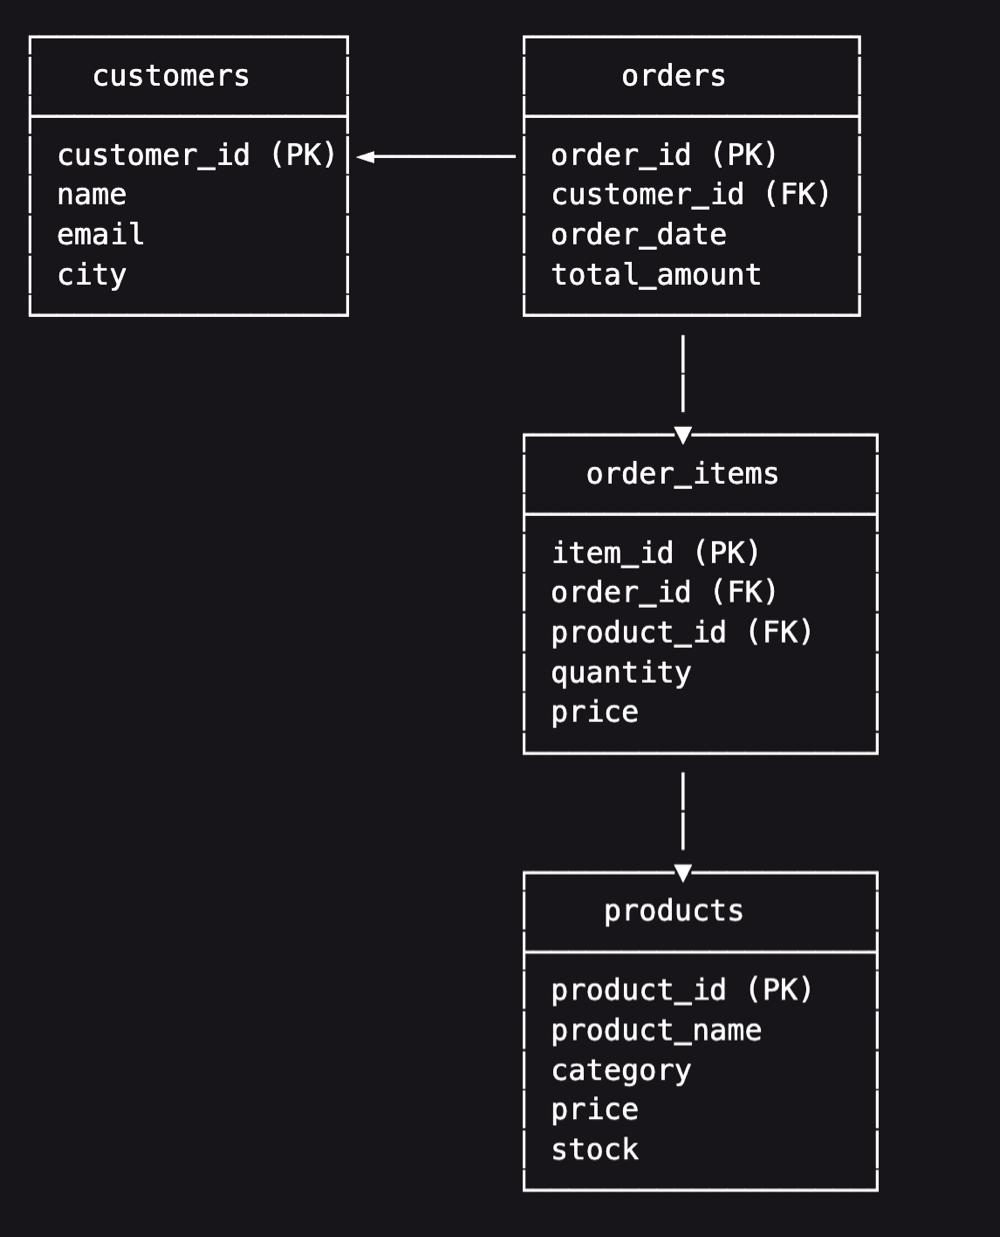

In [ ]:
import sqlite3

# Connect to database (creates file if it doesn't exist)
conn = sqlite3.connect('ecommerce.db')
cursor = conn.cursor()

# Table 1: Customers
cursor.execute('''
CREATE TABLE IF NOT EXISTS customers (
    customer_id INTEGER PRIMARY KEY AUTOINCREMENT,
    name TEXT NOT NULL,
    email TEXT NOT NULL,
    city TEXT,
    signup_date DATE
)
''')


# Table 2: Products
cursor.execute('''
CREATE TABLE IF NOT EXISTS products (
    product_id INTEGER PRIMARY KEY AUTOINCREMENT,
    product_name TEXT NOT NULL,
    category TEXT,
    price REAL NOT NULL,
    stock INTEGER DEFAULT 0
)
''')


# Table 3: Orders
cursor.execute('''
CREATE TABLE IF NOT EXISTS orders (
    order_id INTEGER PRIMARY KEY AUTOINCREMENT,
    customer_id INTEGER NOT NULL,
    order_date DATE NOT NULL,
    total_amount REAL NOT NULL,
    FOREIGN KEY (customer_id) REFERENCES customers(customer_id)
)
''')

# Table 4: Order Items (junction table)
cursor.execute('''
CREATE TABLE IF NOT EXISTS order_items (
    item_id INTEGER PRIMARY KEY AUTOINCREMENT,
    order_id INTEGER NOT NULL,
    product_id INTEGER NOT NULL,
    quantity INTEGER NOT NULL,
    price REAL NOT NULL,
    FOREIGN KEY (order_id) REFERENCES orders(order_id),
    FOREIGN KEY (product_id) REFERENCES products(product_id)
)
''')

# Table 5: Reviews
cursor.execute('''
CREATE TABLE IF NOT EXISTS reviews (
    review_id INTEGER PRIMARY KEY AUTOINCREMENT,
    product_id INTEGER NOT NULL,
    customer_id INTEGER NOT NULL,
    rating INTEGER CHECK(rating >= 1 AND rating <= 5),
    review_text TEXT,
    review_date DATE,
    FOREIGN KEY (product_id) REFERENCES products(product_id),
    FOREIGN KEY (customer_id) REFERENCES customers(customer_id)
)
''')


conn.commit()
print("All tables created successfully!")
conn.close()


All tables created successfully!


In [ ]:
import sqlite3

conn = sqlite3.connect('ecommerce.db')
cursor = conn.cursor()

# Insert customers
customers_data = [
    ('Alice Johnson', 'alice@email.com', 'New York', '2023-01-15'),
    ('Bob Smith', 'bob@email.com', 'Chicago', '2023-02-20'),
    ('Carol White', 'carol@email.com', 'New York', '2023-03-10'),
    ('David Brown', 'david@email.com', 'Los Angeles', '2023-04-05'),
    ('Eve Davis', 'eve@email.com', 'Chicago', '2023-05-12')
]

cursor.executemany('''
INSERT INTO customers (name, email, city, signup_date)
VALUES (?, ?, ?, ?)
''', customers_data)


# Insert products
products_data = [
    ('Laptop', 'Electronics', 999.99, 15),
    ('Wireless Mouse', 'Electronics', 29.99, 50),
    ('Office Chair', 'Furniture', 199.99, 30),
    ('Desk Lamp', 'Furniture', '45.99', 40),
    ('Notebook', 'Stationery', 5.99, 200),
    ('Pen Set', 'Stationery', 12.99, 150),
    ('Monitor', 'Electronics', 299.99, 20),
    ('Keyboard', 'Electronics', 79.99, 35)
]

cursor.executemany('''
INSERT INTO products (product_name, category, price, stock)
VALUES (?, ?, ?, ?)
''', products_data)

# Insert orders
orders_data = [
    (1, '2024-01-15', 1029.98),  # Alice's order
    (2, '2024-01-16', 329.98),   # Bob's order
    (1, '2024-01-20', 45.99),    # Alice's second order
    (3, '2024-01-22', 1299.97),  # Carol's order
    (4, '2024-01-25', 18.98)     # David's order
]

cursor.executemany('''
INSERT INTO orders (customer_id, order_date, total_amount)
VALUES (?, ?, ?)
''', orders_data)

# Insert order items
order_items_data = [
    (1, 1, 1, 999.99),   # Order 1: 1 Laptop
    (1, 2, 1, 29.99),    # Order 1: 1 Mouse
    (2, 7, 1, 299.99),   # Order 2: 1 Monitor
    (2, 2, 1, 29.99),    # Order 2: 1 Mouse
    (3, 4, 1, 45.99),    # Order 3: 1 Desk Lamp
    (4, 1, 1, 999.99),   # Order 4: 1 Laptop
    (4, 7, 1, 299.99),   # Order 4: 1 Monitor
    (5, 5, 2, 5.99),     # Order 5: 2 Notebooks
    (5, 6, 1, 12.99)     # Order 5: 1 Pen Set
]

cursor.executemany('''
INSERT INTO order_items (order_id, product_id, quantity, price)
VALUES (?, ?, ?, ?)
''', order_items_data)

# Insert reviews
reviews_data = [
    (1, 1, 5, 'Excellent laptop! Very fast.', '2024-01-18'),
    (1, NULL, 4, 'Good laptop but a bit pricey.', '2024-01-25'),
    (2, 1, 5, 'Best mouse I ever bought!', '2024-01-17'),
    (7, 2, 4, 'Great monitor, good value.', '2024-01-19'),
    (3, 1, 5, 'Very comfortable chair!', '2024-01-23'),
    (4, 3, 3, 'Lamp is okay, not very bright.', '2024-01-26')
]

cursor.executemany('''
INSERT INTO reviews (product_id, customer_id, rating, review_text, review_date)
VALUES (?, ?, ?, ?, ?)
''', reviews_data)

conn.commit()
print("Sample data inserted successfully!")
conn.close()

NameError: name 'NULL' is not defined

# Veirfy the data inside DB

In [ ]:
conn = sqlite3.connect('ecommerce.db')
cursor = conn.cursor()

# Count rows in each table
tables = ['customers', 'products', 'orders', 'order_items', 'reviews']

for table in tables:
    cursor.execute(f"SeLECT count(*) FROM {table}")
    count = cursor.fetchone()[0]
    print(f"{table}: {count} rows")

conn.close()

customers: 5 rows
products: 8 rows
orders: 5 rows
order_items: 9 rows
reviews: 6 rows


# Data

In [ ]:
import pandas as pd
import sqlite3
import seaborn as sns

# Load Titanic dataset
titanic = sns.load_dataset('titanic')
titanic

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,male,27.0,0,0,13.0000,S,Second,man,True,NaN,Southampton,no,True
887,1,1,female,19.0,0,0,30.0000,S,First,woman,False,B,Southampton,yes,True
888,0,3,female,NaN,1,2,23.4500,S,Third,woman,False,NaN,Southampton,no,False
889,1,1,male,26.0,0,0,30.0000,C,First,man,True,C,Cherbourg,yes,True


In [ ]:
# Connect to database
conn = sqlite3.connect('ecommerce.db')

# Convert DataFrame to SQL table
titanic.to_sql('titanic', conn, if_exists='replace', index=False)

print(f"Titanic table created with {len(titanic)} rows!")

# Verify
cursor = conn.cursor()
cursor.execute("SELECT COUNT(*) FROM titanic")
print(f"Rows in database: {cursor.fetchone()[0]}")

conn.close()

Titanic table created with 891 rows!
Rows in database: 891


In [ ]:
import pandas as pd
import sqlite3
import seaborn as sns

# Load Iris dataset
iris = sns.load_dataset('iris')

iris = iris.loc[50:500]

# Connect to database
conn = sqlite3.connect('ecommerce.db')

# Convert DataFrame to SQL table
iris.to_sql('iris', conn, if_exists='replace', index=False)

print(f"Iris table created with {len(iris)} rows!")

Iris table created with 150 rows!


In [ ]:
conn = sqlite3.connect("ecommerce.db")

query = '''seleCt name From sqlite_master where type='table' '''
tables = pd.read_sql(query, conn)
tables

,name
0,customers
1,sqlite_sequence
2,products
3,orders
4,order_items
5,reviews
6,titanic
7,iris


# Core SQL Querying

In [ ]:
conn = sqlite3.connect('ecommerce.db')

# Select all columns, all rows
query = "SELECT * FROM titanic"
df_sql = pd.read_sql(query, conn)

conn.close()

df_sql

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,1,None,Southampton,no,0
1,1,1,female,38.0,1,0,71.2833,C,First,woman,0,C,Cherbourg,yes,0
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,0,None,Southampton,yes,1
3,1,1,female,35.0,1,0,53.1000,S,First,woman,0,C,Southampton,yes,0
4,0,3,male,35.0,0,0,8.0500,S,Third,man,1,None,Southampton,no,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,male,27.0,0,0,13.0000,S,Second,man,1,None,Southampton,no,1
887,1,1,female,19.0,0,0,30.0000,S,First,woman,0,B,Southampton,yes,1
888,0,3,female,NaN,1,2,23.4500,S,Third,woman,0,None,Southampton,no,0
889,1,1,male,26.0,0,0,30.0000,C,First,man,1,C,Cherbourg,yes,1


In [ ]:
conn = sqlite3.connect('ecommerce.db')

# Select all columns, all rows
query = "SELECT * FROM customers"
df_customers = pd.read_sql(query, conn)

conn.close()

df_customers

,customer_id,name,email,city,signup_date
0,1,Alice Johnson,alice@email.com,New York,2023-01-15
1,2,Bob Smith,bob@email.com,Chicago,2023-02-20
2,3,Carol White,carol@email.com,New York,2023-03-10
3,4,David Brown,david@email.com,Los Angeles,2023-04-05
4,5,Eve Davis,eve@email.com,Chicago,2023-05-12


In [ ]:
conn = sqlite3.connect('ecommerce.db')

# Select all columns, all rows
query = "SELECT * FROM orders"
df_orders = pd.read_sql(query, conn)

conn.close()

df_orders

,order_id,customer_id,order_date,total_amount
0,1,1,2024-01-15,1029.98
1,2,2,2024-01-16,329.98
2,3,1,2024-01-20,45.99
3,4,3,2024-01-22,1299.97
4,5,4,2024-01-25,18.98


In [ ]:
conn = sqlite3.connect('ecommerce2.db')

# Select all columns, all rows
query = "SELECT * FROM customer_retention"
df_2 = pd.read_sql(query, conn)

conn.close()

df_sql

In [ ]:
conn = sqlite3.connect('ecommerce.db')

query = "SELECT sex, age FROM titanic"
df = pd.read_sql(query, conn)
df


,sex,age
0,male,22.0
1,female,38.0
2,female,26.0
3,female,35.0
4,male,35.0
...,...,...
886,male,27.0
887,female,19.0
888,female,NaN
889,male,26.0


In [ ]:
df2 = sns.load_dataset("titanic")
df2[['sex', 'age']]

,sex,age
0,male,22.0
1,female,38.0
2,female,26.0
3,female,35.0
4,male,35.0
...,...,...
886,male,27.0
887,female,19.0
888,female,NaN
889,male,26.0


In [ ]:
conn = sqlite3.connect('ecommerce.db')

query = "SELECT survived, pclass, sex, age, fare FROM titanic"
df = pd.read_sql(query, conn)
df


,survived,pclass,sex,age,fare
0,0,3,male,22.0,7.2500
1,1,1,female,38.0,71.2833
2,1,3,female,26.0,7.9250
3,1,1,female,35.0,53.1000
4,0,3,male,35.0,8.0500
...,...,...,...,...,...
886,0,2,male,27.0,13.0000
887,1,1,female,19.0,30.0000
888,0,3,female,NaN,23.4500
889,1,1,male,26.0,30.0000


In [ ]:
df2[['survived', 'pclass', 'sex', 'age', 'fare']]

,survived,pclass,sex,age,fare
0,0,3,male,22.0,7.2500
1,1,1,female,38.0,71.2833
2,1,3,female,26.0,7.9250
3,1,1,female,35.0,53.1000
4,0,3,male,35.0,8.0500
...,...,...,...,...,...
886,0,2,male,27.0,13.0000
887,1,1,female,19.0,30.0000
888,0,3,female,NaN,23.4500
889,1,1,male,26.0,30.0000


In [ ]:
conn = sqlite3.connect('ecommerce.db')

query = "SELECT sex, age, survived FROM titanic WHERE sex = 'female'"
df_sql = pd.read_sql(query, conn)

print(df_sql.head())
print(f"\nTotal female passengers: {len(df_sql)}")



      sex   age  survived
0  female  38.0         1
1  female  26.0         1
2  female  35.0         1
3  female  27.0         1
4  female  14.0         1

Total female passengers: 314


In [ ]:
query = "SELECT pclass, sex, age, fare FROM titanic WHERE pclass = 1"
df_sql = pd.read_sql(query, conn)

print(df_sql.head())
print(f"\nFirst class passengers: {len(df_sql)}")

   pclass     sex   age     fare
0       1  female  38.0  71.2833
1       1  female  35.0  53.1000
2       1    male  54.0  51.8625
3       1  female  58.0  26.5500
4       1    male  28.0  35.5000

First class passengers: 216


In [ ]:
query = "SELECT *  FROM customers WHERE name='Bob Smith' "
df_sql = pd.read_sql(query, conn)

print(df_sql.head())
print(f"\nFirst class passengers: {len(df_sql)}")

   customer_id       name          email     city signup_date
0            2  Bob Smith  bob@email.com  Chicago  2023-02-20

First class passengers: 1


In [ ]:
# Passengers older than 60
query = "SELECT sex, age, pclass FROM titanic WHERE age > 60"
df_sql = pd.read_sql(query, conn)

print(df_sql.head(10))
print(f"\nPassengers over 60: {len(df_sql)}")


      sex   age  pclass
0    male  66.0       2
1    male  65.0       1
2    male  71.0       1
3    male  70.5       3
4    male  61.0       1
5    male  62.0       1
6  female  63.0       1
7    male  65.0       3
8    male  61.0       3
9    male  64.0       1

Passengers over 60: 22


In [ ]:
titanic[titanic['age'] > 60][['sex', 'age', 'pclass']]

In [ ]:
query = "SELECT sex, age, fare, pclass FROM titanic WHERE fare <= 10"
df_sql = pd.read_sql(query, conn)

print(df_sql.head())
print(f"\nCheap tickets (≤ £10): {len(df_sql)}")

      sex   age    fare  pclass
0    male  22.0  7.2500       3
1  female  26.0  7.9250       3
2    male  35.0  8.0500       3
3    male   NaN  8.4583       3
4    male  20.0  8.0500       3

Cheap tickets (≤ £10): 336


In [ ]:
query = """
SELECT sex, pclass, age, fare
FROM titanic
WHERE sex = 'female' AND pclass = 1
"""
df_sql = pd.read_sql(query, conn)

print(df_sql.head())
print(f"\nFirst class women: {len(df_sql)}")

      sex  pclass   age      fare
0  female       1  38.0   71.2833
1  female       1  35.0   53.1000
2  female       1  58.0   26.5500
3  female       1   NaN  146.5208
4  female       1  49.0   76.7292

First class women: 94


In [ ]:
df_pandas = titanic[
    (titanic['sex'] == 'female') & (titanic['pclass'] == 1)
][['sex', 'pclass', 'age', 'fare']]


In [ ]:

conn = sqlite3.connect('ecommerce.db')
# Passengers from Cherbourg OR Queenstown
query = """
SELECT sex, age, embarked, pclass
FROM titanic
WHERE embarked = 'C' OR embarked = 'Q'
"""
df_sql = pd.read_sql(query, conn)

print(df_sql.head())
print(f"\nFrom C or Q: {len(df_sql)}")

      sex   age embarked  pclass
0  female  38.0        C       1
1    male   NaN        Q       3
2  female  14.0        C       2
3    male   2.0        Q       3
4  female   NaN        C       3

From C or Q: 245


In [ ]:
# Passengers from specific ports
query = """
SELECT sex, age, embarked, fare
FROM titanic
WHERE embarked IN ('C', 'Q')
"""
# WHERE embarked = 'C' OR embarked = 'Q'

df_sql = pd.read_sql(query, conn)

print(df_sql.head())
print(f"\nFrom C or Q: {len(df_sql)}")

In [ ]:
titanic[
    titanic['embarked'].isin(['C', 'Q'])
][['sex', 'age', 'embarked', 'fare']]

In [ ]:
# First or second class only
query = """
SELECT pclass, sex, age, fare
FROM titanic
WHERE pclass IN (1, 2);
"""
df_sql = pd.read_sql(query, conn)

print(df_sql.head())
print(f"\nFirst or second class: {len(df_sql)}")

   pclass     sex   age     fare
0       1  female  38.0  71.2833
1       1  female  35.0  53.1000
2       1    male  54.0  51.8625
3       2  female  14.0  30.0708
4       1  female  58.0  26.5500

First or second class: 400


In [ ]:
# Mid-range fares
query = """
SELECT sex, age, fare, pclass
FROM titanic
WHERE fare BETWEEN 50 AND 100
"""
df_sql = pd.read_sql(query, conn)

print(df_sql.head())
print(f"\nFares £50-£100: {len(df_sql)}")

      sex   age     fare  pclass
0  female  38.0  71.2833       1
1  female  35.0  53.1000       1
2    male  54.0  51.8625       1
3    male  28.0  82.1708       1
4    male  42.0  52.0000       1

Fares £50-£100: 108


In [ ]:
df2

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,male,27.0,0,0,13.0000,S,Second,man,True,NaN,Southampton,no,True
887,1,1,female,19.0,0,0,30.0000,S,First,woman,False,B,Southampton,yes,True
888,0,3,female,NaN,1,2,23.4500,S,Third,woman,False,NaN,Southampton,no,False
889,1,1,male,26.0,0,0,30.0000,C,First,man,True,C,Cherbourg,yes,True


In [ ]:
df2['class'].unique()

['Third', 'First', 'Second']
Categories (3, object): ['First', 'Second', 'Third']

In [ ]:
query = "SELECT DISTINCT pclass FROM titanic"
df_sql = pd.read_sql(query, conn)
df_sql

,pclass
0,3
1,1
2,2


In [ ]:
query = "SELECT DISTINCT embarked FROM titanic"
df_sql = pd.read_sql(query, conn)

print(df_sql)

  embarked
0        S
1        C
2        Q
3     None


In [ ]:
query = """
SELECT sex, age, pclass, fare
FROM titanic
ORDER BY age Desc
"""
df_sql = pd.read_sql(query, conn)

print(df_sql.head(10))

    sex   age  pclass     fare
0  male  80.0       1  30.0000
1  male  74.0       3   7.7750
2  male  71.0       1  34.6542
3  male  71.0       1  49.5042
4  male  70.5       3   7.7500
5  male  70.0       2  10.5000
6  male  70.0       1  71.0000
7  male  66.0       2  10.5000
8  male  65.0       1  61.9792
9  male  65.0       3   7.7500


In [ ]:
query = """
SELECT sex, age, pclass, fare
FROM titanic
ORDER BY fare DESC
"""
df_sql = pd.read_sql(query, conn)
df_sql

,sex,age,pclass,fare
0,female,35.0,1,512.3292
1,male,36.0,1,512.3292
2,male,35.0,1,512.3292
3,male,19.0,1,263.0000
4,female,23.0,1,263.0000
...,...,...,...,...
886,male,NaN,2,0.0000
887,male,NaN,2,0.0000
888,male,39.0,1,0.0000
889,male,NaN,1,0.0000


In [ ]:
query = """
SELECT pclass, sex, age, fare
FROM titanic
ORDER BY pclass ASC, fare DESC
"""
df_sql = pd.read_sql(query, conn)

print(df_sql.head(10))

   pclass     sex   age      fare
0       1  female  35.0  512.3292
1       1    male  36.0  512.3292
2       1    male  35.0  512.3292
3       1    male  19.0  263.0000
4       1  female  23.0  263.0000
5       1  female  24.0  263.0000
6       1    male  64.0  263.0000
7       1  female  18.0  262.3750
8       1  female  21.0  262.3750
9       1    male  24.0  247.5208


In [ ]:
df_pandas = titanic[['pclass', 'sex', 'age', 'fare']].sort_values(
    ['pclass', 'fare'],
    ascending=[True, False]
)

In [ ]:
query = """
SELECT sex, age, pclass, survived
FROM titanic
ORDER BY sex ASC, age DESC
"""
df_sql = pd.read_sql(query, conn)

print(df_sql.head(10))


      sex   age  pclass  survived
0  female  63.0       1         1
1  female  63.0       3         1
2  female  62.0       1         1
3  female  60.0       1         1
4  female  58.0       1         1
5  female  58.0       1         1
6  female  58.0       1         1
7  female  57.0       2         0
8  female  56.0       1         1
9  female  55.0       2         1


In [ ]:
query = "SELECT sex, age, pclass, fare FROM titanic LIMIT 10"
df_sql = pd.read_sql(query, conn)

print(df_sql)

      sex   age  pclass     fare
0    male  22.0       3   7.2500
1  female  38.0       1  71.2833
2  female  26.0       3   7.9250
3  female  35.0       1  53.1000
4    male  35.0       3   8.0500
5    male   NaN       3   8.4583
6    male  54.0       1  51.8625
7    male   2.0       3  21.0750
8  female  27.0       3  11.1333
9  female  14.0       2  30.0708


In [ ]:
query = """
SELECT sex, age, pclass, fare
FROM titanic

ORDER BY fare DESC
LIMIT 10
"""
df_sql = pd.read_sql(query, conn)

print(df_sql)

      sex   age  pclass      fare
0  female  35.0       1  512.3292
1    male  36.0       1  512.3292
2    male  35.0       1  512.3292
3    male  19.0       1  263.0000
4  female  23.0       1  263.0000
5  female  24.0       1  263.0000
6    male  64.0       1  263.0000
7  female  18.0       1  262.3750
8  female  21.0       1  262.3750
9    male  24.0       1  247.5208


In [ ]:
query = """
SELECT sex as gender
, age as passenger_age
, pclass as ticket_class
, fare as ticket_price
FROM titanic

ORDER BY fare DESC
LIMIT 10
"""

df_sql = pd.read_sql(query, conn)

print(df_sql)

   gender  passenger_age  ticket_class  ticket_price
0  female           35.0             1      512.3292
1    male           36.0             1      512.3292
2    male           35.0             1      512.3292
3    male           19.0             1      263.0000
4  female           23.0             1      263.0000
5  female           24.0             1      263.0000
6    male           64.0             1      263.0000
7  female           18.0             1      262.3750
8  female           21.0             1      262.3750
9    male           24.0             1      247.5208


In [ ]:
query = """
SELECT
    sex,
    age,
    fare,
    fare * 1.2 AS fare_with_tax
FROM titanic
LIMIT 5
"""
df_sql = pd.read_sql(query, conn)

print(df_sql)

      sex   age     fare  fare_with_tax
0    male  22.0   7.2500        8.70000
1  female  38.0  71.2833       85.53996
2  female  26.0   7.9250        9.51000
3  female  35.0  53.1000       63.72000
4    male  35.0   8.0500        9.66000


In [ ]:
query = """
SELECT
    sex,
    age,
    fare,
    fare * age AS fare_with_tax
FROM titanic
LIMIT 5
"""
df_sql = pd.read_sql(query, conn)

print(df_sql)

      sex   age     fare  fare_with_tax
0    male  22.0   7.2500       159.5000
1  female  38.0  71.2833      2708.7654
2  female  26.0   7.9250       206.0500
3  female  35.0  53.1000      1858.5000
4    male  35.0   8.0500       281.7500


In [ ]:
query = """
SELECT
    sex || ' passenger' as passenger_type,
    age,
    fare,
    fare * age AS fare_with_tax
FROM titanic
LIMIT 5
"""
df_sql = pd.read_sql(query, conn)

print(df_sql)

     passenger_type   age     fare  fare_with_tax
0    male passenger  22.0   7.2500       159.5000
1  female passenger  38.0  71.2833      2708.7654
2  female passenger  26.0   7.9250       206.0500
3  female passenger  35.0  53.1000      1858.5000
4    male passenger  35.0   8.0500       281.7500


In [ ]:
query = """
SELECT
    sex,
    age,
    CASE
        WHEN age < 18 THEN 'Child'
        WHEN age >= 18 AND age < 60 THEN 'Adult'
        ELSE 'Senior'
    END AS age_group
FROM titanic
LIMIT 10
"""
df_sql = pd.read_sql(query, conn)

print(df_sql)

      sex   age age_group
0    male  22.0     Adult
1  female  38.0     Adult
2  female  26.0     Adult
3  female  35.0     Adult
4    male  35.0     Adult
5    male   NaN    Senior
6    male  54.0     Adult
7    male   2.0     Child
8  female  27.0     Adult
9  female  14.0     Child


In [ ]:
query = """
SELECT sex, age, CASE WHEN age < 18 THEN 'Child' WHEN age >= 18 AND age < 60 THEN 'Adult' ELSE 'Senior' END AS age_group FROM titanic LIMIT 10
"""
df_sql = pd.read_sql(query, conn)

print(df_sql)

      sex   age age_group
0    male  22.0     Adult
1  female  38.0     Adult
2  female  26.0     Adult
3  female  35.0     Adult
4    male  35.0     Adult
5    male   NaN    Senior
6    male  54.0     Adult
7    male   2.0     Child
8  female  27.0     Adult
9  female  14.0     Child


In [ ]:
query = """
SELECT sex, age, pclass, fare
FROM titanic
WHERE age IS NULL
LIMIT 10
"""
df_sql = pd.read_sql(query, conn)
df_sql

,sex,age,pclass,fare
0,male,None,3,8.4583
1,male,None,2,13.0000
2,female,None,3,7.2250
3,male,None,3,7.2250
4,female,None,3,7.8792
5,male,None,3,7.8958
6,female,None,1,146.5208
7,female,None,3,7.7500
8,male,None,3,7.2292
9,male,None,3,7.8958


In [ ]:
query = """
SELECT sex, age, pclass, fare
FROM titanic
WHERE age IS NOT NULL
LIMIT 10
"""
df_sql = pd.read_sql(query, conn)
df_sql

,sex,age,pclass,fare
0,male,22.0,3,7.2500
1,female,38.0,1,71.2833
2,female,26.0,3,7.9250
3,female,35.0,1,53.1000
4,male,35.0,3,8.0500
5,male,54.0,1,51.8625
6,male,2.0,3,21.0750
7,female,27.0,3,11.1333
8,female,14.0,2,30.0708
9,female,4.0,3,16.7000


In [ ]:
query = """
SELECT sex, age, pclass, survived
FROM titanic
WHERE sex = 'female' AND age IS NULL
LIMIT 10
"""
df_sql = pd.read_sql(query, conn)

print(df_sql)

      sex   age  pclass  survived
0  female  None       3         1
1  female  None       3         1
2  female  None       1         1
3  female  None       3         1
4  female  None       3         1
5  female  None       3         1
6  female  None       3         1
7  female  None       3         1
8  female  None       3         0
9  female  None       1         1


In [ ]:
SELECT DISTINCT * FROM customers;


Find the 5 unique ticket classes and genders of passengers who embarked from Southampton or Cherbourg, were aged between 25 and 50, paid more than £30, and have a known age — sorted by fare (highest first). Show the class as 'Ticket Class', gender as 'Gender', age as 'Passenger Age', and fare as 'Ticket Price'.